# **1. Baseline MLP**

Using Device: cuda


100%|██████████| 170M/170M [00:15<00:00, 11.3MB/s]



Training for lambda = 0.0001
Lambda 0.0001 | Epoch 1/10 | Loss 31439.47 | Test Acc 40.46%
Lambda 0.0001 | Epoch 2/10 | Loss 26166.15 | Test Acc 44.40%
Lambda 0.0001 | Epoch 3/10 | Loss 21366.07 | Test Acc 46.38%
Lambda 0.0001 | Epoch 4/10 | Loss 17212.39 | Test Acc 47.82%
Lambda 0.0001 | Epoch 5/10 | Loss 13789.11 | Test Acc 49.17%
Lambda 0.0001 | Epoch 6/10 | Loss 11080.07 | Test Acc 49.67%
Lambda 0.0001 | Epoch 7/10 | Loss 8984.23 | Test Acc 50.01%
Lambda 0.0001 | Epoch 8/10 | Loss 7374.68 | Test Acc 51.34%
Lambda 0.0001 | Epoch 9/10 | Loss 6136.07 | Test Acc 52.09%
Lambda 0.0001 | Epoch 10/10 | Loss 5172.34 | Test Acc 51.80%

Training for lambda = 0.001
Lambda 0.001 | Epoch 1/10 | Loss 307616.17 | Test Acc 40.21%
Lambda 0.001 | Epoch 2/10 | Loss 255280.39 | Test Acc 44.81%
Lambda 0.001 | Epoch 3/10 | Loss 207052.38 | Test Acc 45.94%
Lambda 0.001 | Epoch 4/10 | Loss 164996.96 | Test Acc 47.91%
Lambda 0.001 | Epoch 5/10 | Loss 130197.33 | Test Acc 47.46%
Lambda 0.001 | Epoch 6/10 | L

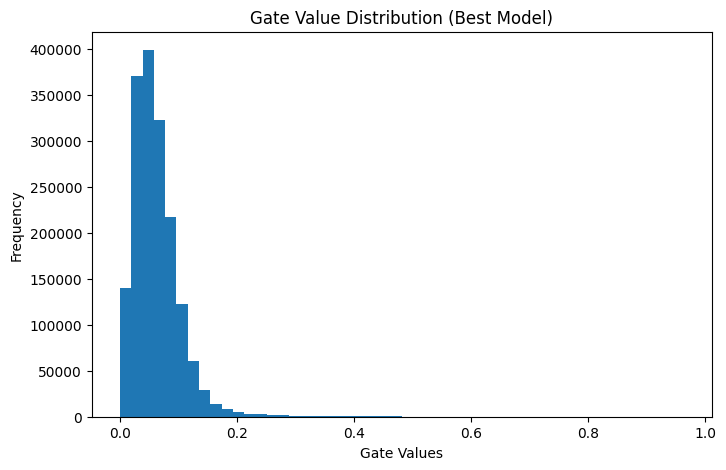


Files Saved:
results.csv
best_model.pth


In [1]:
# ============================================================
# TREDENCE AI ENGINEERING INTERN CASE STUDY
# Self-Pruning Neural Network on CIFAR-10
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# ============================================================
# CONFIG
# ============================================================

BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001
LAMBDAS = [0.0001, 0.001, 0.01]

# ============================================================
# DATASET
# ============================================================

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE,
                         shuffle=True, num_workers=2)

testloader = DataLoader(testset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2)

# ============================================================
# PRUNABLE LINEAR LAYER
# ============================================================

class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(
            torch.randn(out_features, in_features) * 0.01
        )

        self.bias = nn.Parameter(torch.zeros(out_features))

        self.gate_scores = nn.Parameter(
            torch.randn(out_features, in_features)
        )

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

# ============================================================
# MODEL
# ============================================================

class SelfPruningNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = PrunableLinear(3*32*32, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ============================================================
# SPARSITY LOSS
# ============================================================

def sparsity_loss(model):
    loss = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += gates.sum()
    return loss

# ============================================================
# TEST ACCURACY
# ============================================================

def evaluate(model):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    return acc

# ============================================================
# CALCULATE SPARSITY %
# ============================================================

def calculate_sparsity(model, threshold=1e-2):
    total = 0
    zeroed = 0

    gate_values_all = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()

            total += gates.size
            zeroed += np.sum(gates < threshold)

            gate_values_all.extend(gates.flatten())

    sparsity = 100 * zeroed / total
    return sparsity, gate_values_all

# ============================================================
# TRAIN FUNCTION
# ============================================================

def train_model(lambda_val):

    model = SelfPruningNet().to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    for epoch in range(EPOCHS):

        model.train()
        running_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            cls_loss = criterion(outputs, labels)
            sparse_loss = sparsity_loss(model)

            total_loss = cls_loss + lambda_val * sparse_loss

            total_loss.backward()
            optimizer.step()

            running_loss += total_loss.item()

        acc = evaluate(model)

        print(f"Lambda {lambda_val} | Epoch {epoch+1}/{EPOCHS} "
              f"| Loss {running_loss:.2f} | Test Acc {acc:.2f}%")

    final_acc = evaluate(model)
    sparsity, gate_vals = calculate_sparsity(model)

    return model, final_acc, sparsity, gate_vals

# ============================================================
# RUN EXPERIMENTS
# ============================================================

results = []

best_model = None
best_gates = None
best_acc = 0

for lam in LAMBDAS:

    print("\n==============================")
    print("Training for lambda =", lam)
    print("==============================")

    model, acc, sparsity, gates = train_model(lam)

    results.append([lam, round(acc,2), round(sparsity,2)])

    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_gates = gates

# ============================================================
# RESULTS TABLE
# ============================================================

df = pd.DataFrame(results,
                  columns=["Lambda", "Test Accuracy", "Sparsity %"])

print("\nFinal Results")
print(df)

# ============================================================
# PLOT GATE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))
plt.hist(best_gates, bins=50)
plt.title("Gate Value Distribution (Best Model)")
plt.xlabel("Gate Values")
plt.ylabel("Frequency")
plt.show()

# ============================================================
# SAVE RESULTS
# ============================================================

df.to_csv("results.csv", index=False)
torch.save(best_model.state_dict(), "best_model.pth")

print("\nFiles Saved:")
print("results.csv")
print("best_model.pth")

# **2. CNN Model**

Using Device: cuda

Training Lambda = 0.0001
Lambda 0.0001 | Epoch 1/15 | Loss 19598.78 | Acc 48.65%
Lambda 0.0001 | Epoch 2/15 | Loss 16299.83 | Acc 54.56%
Lambda 0.0001 | Epoch 3/15 | Loss 13334.62 | Acc 59.62%
Lambda 0.0001 | Epoch 4/15 | Loss 10775.28 | Acc 61.40%
Lambda 0.0001 | Epoch 5/15 | Loss 8676.23 | Acc 63.94%
Lambda 0.0001 | Epoch 6/15 | Loss 7018.28 | Acc 66.71%
Lambda 0.0001 | Epoch 7/15 | Loss 5742.83 | Acc 67.71%
Lambda 0.0001 | Epoch 8/15 | Loss 4756.47 | Acc 68.23%
Lambda 0.0001 | Epoch 9/15 | Loss 3997.97 | Acc 69.76%
Lambda 0.0001 | Epoch 10/15 | Loss 3406.99 | Acc 69.13%
Lambda 0.0001 | Epoch 11/15 | Loss 2939.44 | Acc 70.24%
Lambda 0.0001 | Epoch 12/15 | Loss 2563.26 | Acc 70.10%
Lambda 0.0001 | Epoch 13/15 | Loss 2263.16 | Acc 70.76%
Lambda 0.0001 | Epoch 14/15 | Loss 2015.19 | Acc 71.53%
Lambda 0.0001 | Epoch 15/15 | Loss 1809.92 | Acc 71.12%

Training Lambda = 0.001
Lambda 0.001 | Epoch 1/15 | Loss 189657.18 | Acc 50.01%
Lambda 0.001 | Epoch 2/15 | Loss 157374

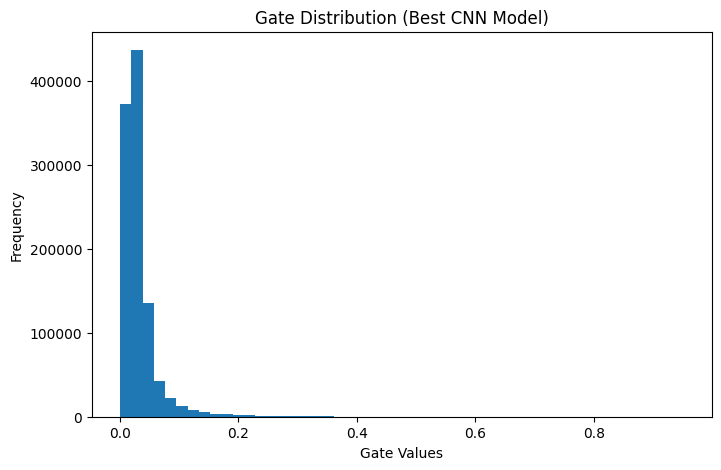


Saved:
cnn_results.csv
cnn_best_model.pth


In [2]:
# ==========================================================
# ADVANCED CNN SELF-PRUNING NETWORK (CIFAR-10)
# Better than MLP baseline
# Google Colab Ready
# ==========================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# ==========================================================
# CONFIG
# ==========================================================

BATCH_SIZE = 128
EPOCHS = 15
LR = 0.001
LAMBDAS = [0.0001, 0.001, 0.01]

# ==========================================================
# DATA
# ==========================================================

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE,
                         shuffle=True, num_workers=2)

testloader = DataLoader(testset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2)

# ==========================================================
# PRUNABLE LINEAR
# ==========================================================

class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(
            torch.randn(out_features, in_features) * 0.02
        )

        self.bias = nn.Parameter(torch.zeros(out_features))

        self.gate_scores = nn.Parameter(
            torch.randn(out_features, in_features)
        )

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weight = self.weight * gates
        return F.linear(x, pruned_weight, self.bias)

# ==========================================================
# CNN MODEL
# ==========================================================

class CNNPruningNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = PrunableLinear(64 * 8 * 8, 256)
        self.fc2 = PrunableLinear(256, 10)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))   # 32x16x16
        x = self.pool(F.relu(self.conv2(x)))   # 64x8x8

        x = x.view(x.size(0), -1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

# ==========================================================
# SPARSITY LOSS
# ==========================================================

def sparsity_loss(model):
    loss = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += gates.sum()
    return loss

# ==========================================================
# TEST
# ==========================================================

def evaluate(model):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, pred = torch.max(outputs,1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    return 100 * correct / total

# ==========================================================
# SPARSITY %
# ==========================================================

def calc_sparsity(model, threshold=1e-2):

    total = 0
    zeroed = 0
    gate_vals = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):

            g = torch.sigmoid(module.gate_scores).detach().cpu().numpy()

            total += g.size
            zeroed += np.sum(g < threshold)

            gate_vals.extend(g.flatten())

    return 100 * zeroed / total, gate_vals

# ==========================================================
# TRAIN
# ==========================================================

def train_model(lambda_val):

    model = CNNPruningNet().to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    for epoch in range(EPOCHS):

        model.train()
        running_loss = 0

        for images, labels in trainloader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            ce = criterion(outputs, labels)
            sp = sparsity_loss(model)

            loss = ce + lambda_val * sp

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        acc = evaluate(model)

        print(f"Lambda {lambda_val} | "
              f"Epoch {epoch+1}/{EPOCHS} | "
              f"Loss {running_loss:.2f} | "
              f"Acc {acc:.2f}%")

    final_acc = evaluate(model)
    sparsity, gates = calc_sparsity(model)

    return model, final_acc, sparsity, gates

# ==========================================================
# RUN ALL
# ==========================================================

results = []
best_acc = 0
best_gates = None
best_model = None

for lam in LAMBDAS:

    print("\n========================")
    print("Training Lambda =", lam)
    print("========================")

    model, acc, sp, gates = train_model(lam)

    results.append([lam, round(acc,2), round(sp,2)])

    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_gates = gates

# ==========================================================
# RESULTS
# ==========================================================

df = pd.DataFrame(results,
                  columns=["Lambda","Accuracy","Sparsity %"])

print("\nFinal Results")
print(df)

# ==========================================================
# HISTOGRAM
# ==========================================================

plt.figure(figsize=(8,5))
plt.hist(best_gates, bins=50)
plt.title("Gate Distribution (Best CNN Model)")
plt.xlabel("Gate Values")
plt.ylabel("Frequency")
plt.show()

# ==========================================================
# SAVE
# ==========================================================

df.to_csv("cnn_results.csv", index=False)
torch.save(best_model.state_dict(), "cnn_best_model.pth")

print("\nSaved:")
print("cnn_results.csv")
print("cnn_best_model.pth")